In [1]:
import pandas as pd
import numpy as np
import re
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def _plot_transition_heatmap(df, adapter_name):
    directory_path = f'./analysis/{adapter_name}'
    os.makedirs(directory_path, exist_ok=True)
    crosstab = pd.crosstab(df["group_before"], df["group_after"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Knowledge State Transition - {adapter_name}")
    plt.ylabel("Before")
    plt.xlabel("After")
    plt.tight_layout()
    plt.savefig(f'{directory_path}/knowledge_state_transition.png', dpi=300, bbox_inches='tight')
    plt.show()

def _plot_shift_bars(psc, nsc, count_p, count_n, adapter_name):
    directory_path = f'./analysis/{adapter_name}'
    os.makedirs(directory_path, exist_ok=True)
    fig, ax = plt.subplots()
    ax.bar(["PSC", "NSC"], [psc, nsc], color=["green", "red"])
    ax.set_title(f"Shift Scores for {adapter_name}")
    for i, val in enumerate([psc, nsc]):
        ax.text(i, val + 0.01, f"{val:.2f} ({[count_p, count_n][i]} samples)", ha='center')
    plt.tight_layout()
    plt.savefig(f'{directory_path}/shift_scores.png', dpi=300, bbox_inches='tight')
    plt.show()

def _compute_accuracy(df):
    trained = df[df["trained"]]
    if trained.empty:
        return 0.0
    return trained["sc_after"].mean()

def _assign_knowledge_groups(df):
    def get_group(sc):
        if sc == 1.0:
            return "HK"
        elif sc == 0.0:
            return "UK"
        else:
            return "PK"

    df["group_before"] = df["sc_before"].apply(get_group)
    df["group_after"] = df["sc_after"].apply(get_group)
    return df

def _sanitize(name: str) -> str:
    """Make a string safe for use as a column name."""
    return re.sub(r'[^0-9a-zA-Z]+', '_', name).strip('_')

def _compute_shifts(df):
    df["sc_shift"] = df["sc_after"] - df["sc_before"]
    mask = (
        (df["group_before"] != "UK") |
        ((df["group_before"] == "UK") & (df["is_validation"]))
    )
    filtered = df[~df["trained"] & mask]

    #Positive shift
    pos_df = filtered[filtered["sc_shift"] > 0.2]
    psc = pos_df["sc_shift"].abs().sum()
    count_p = len(pos_df)

    #Negative shift
    neg_df = filtered[filtered["sc_shift"] < -0.2]
    nsc = neg_df["sc_shift"].abs().sum()
    count_n = len(neg_df)

    return psc, count_p, nsc, count_n

In [3]:
def load_json_to_df(
    json_path: str,
):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"File not found: {json_path}")

    rows = []
    ft_model_names = set()
    base_ids = set()

    # First pass: collect all FT model names and base ids
    with open(json_path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            base_eval = obj.get("base_eval", {})
            b_id = base_eval.get("model_id")
            if b_id:
                base_ids.add(b_id)
            ft = obj.get("ft_evals", {}) or {}
            for k in ft.keys():
                ft_model_names.add(k)

    ft_model_names = sorted(ft_model_names)
    base_ids = sorted(base_ids)

    # Map FT model to (score_col, train_col)
    model_to_cols = {}
    ft_score_cols, ft_train_cols = [], []
    for m in ft_model_names:
        s = _sanitize(m)
        sc_col = f"{s}_score"
        tr_col = f"{s}_train"
        model_to_cols[m] = (sc_col, tr_col)
        ft_score_cols.append(sc_col)
        ft_train_cols.append(tr_col)

    # Second pass: build rows
    with open(json_path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)

            qid = obj.get("id")
            is_val = bool(obj.get("is_validation", False))

            base_eval = obj.get("base_eval", {}) or {}
            base_model_id = base_eval.get("model_id")
            base_score = base_eval.get("score", 0.0)

            # Your rule: if base score != 0 → set validation to True
            if (base_score is not None) and (float(base_score) != 0.0):
                is_val = True

            rec = {
                "qid": qid,
                "is_validation": is_val,
                "base_model_id": base_model_id,
                "base_score": float(base_score) if base_score is not None else np.nan,
            }

            # one column per base id: base_<id>_score
            for b in base_ids:
                rec[f"base_{_sanitize(b)}_score"] = np.nan
            if base_model_id:
                rec[f"base_{_sanitize(base_model_id)}_score"] = rec["base_score"]

            # init FT cols
            for m in ft_model_names:
                sc_col, tr_col = model_to_cols[m]
                rec[sc_col] = np.nan
                rec[tr_col] = False

            # fill FT values present in this record
            ft = obj.get("ft_evals", {}) or {}
            for m, payload in ft.items():
                sc_col, tr_col = model_to_cols[m]
                if isinstance(payload, dict):
                    if "score" in payload:
                        rec[sc_col] = float(payload["score"])
                    if "train" in payload:
                        rec[tr_col] = bool(payload["train"])

            rows.append(rec)

    df = pd.DataFrame(rows)

    base_score_cols = [f"base_{_sanitize(b)}_score" for b in base_ids]

    return df, ft_model_names, ft_score_cols, ft_train_cols, base_score_cols

In [4]:
def evaluate_single_run(
    df: pd.DataFrame,
    ft_model_name: str,
    base_model_name: str,
):
    s_ft = _sanitize(ft_model_name)
    s_base = _sanitize(base_model_name)
    ft_score_col = f"{s_ft}_score"
    ft_train_col = f"{s_ft}_train"
    base_score_col = f"base_{s_base}_score"

    # Prepare evaluation DataFrame
    eval_df = pd.DataFrame({
        "sc_before": df[base_score_col],
        "sc_after": df[ft_score_col],
        "trained": df[ft_train_col],
        "is_validation": df["is_validation"],
        "qid": df["qid"],
    })

    eval_df = _assign_knowledge_groups(eval_df)

    acc = _compute_accuracy(eval_df)
    n_train = eval_df["trained"].sum()
    psc, count_p, nsc, count_n = _compute_shifts(eval_df)

    print(f"Adapter: {ft_model_name}")
    print(f"Baseline: {base_model_name}")
    print(f"Trained samples: {n_train}")
    print(f"Accuracy: {acc:.3f}")
    print(f"PSC: {psc:.3f} ({count_p} samples)")
    print(f"NSC: {nsc:.3f} ({count_n} samples)")

    _plot_shift_bars(psc, nsc, count_p, count_n, ft_model_name)
    _plot_transition_heatmap(eval_df, ft_model_name)

In [5]:
def evaluate_single_adapter_by_trainedN(
    df: pd.DataFrame,
    adapter_model_names: list, 
    adapter_name: str,
    base_model_name: str = ""
):
    """
    Evaluate one adapter family across multiple training sizes/runs.
    For each raw model name in `adapter_model_names` we:
      - sanitize it to find the matching *_score and *_train columns
      - use the same baseline column for sc_before (either base_<id>_score or base_score)
    """
    directory_path = f'./analysis/{adapter_name}'
    os.makedirs(directory_path, exist_ok=True)
    # baseline column
    if base_model_name:
        s_base = _sanitize(base_model_name)
        base_score_col = f"base_{s_base}_score"
    else:
        base_score_col = "base_score"

    # sanity check: baseline must exist
    if base_score_col not in df.columns:
        raise KeyError(f"Baseline column '{base_score_col}' not found in df.columns")

    results = []

    for raw_name in adapter_model_names:
        s = _sanitize(raw_name)
        score_col = f"{s}_score"
        train_col = f"{s}_train"

        # sanity checks per model
        missing = [c for c in (score_col, train_col) if c not in df.columns]
        if missing:
            raise KeyError(f"For model '{raw_name}', missing columns: {missing}. "
                           f"Did you pass raw names? (e.g., '..._tr100')")

        eval_df = pd.DataFrame({
            "sc_before": df[base_score_col],
            "sc_after": df[score_col],
            "trained": df[train_col],
            "is_validation": df["is_validation"],
            "qid": df["qid"],
        })

        eval_df = _assign_knowledge_groups(eval_df)

        acc = _compute_accuracy(eval_df)
        n_train = int(eval_df["trained"].sum())
        psc, count_p, nsc, count_n = _compute_shifts(eval_df)

        results.append({
            "model": raw_name,
            "n_trained": n_train,
            "accuracy": acc,
            "psc": psc,
            "nsc": nsc,
            "psc_count": count_p,
            "nsc_count": count_n,
        })
    results_df = pd.DataFrame(results)
    results_df.to_csv(f'{directory_path}/uiortholora_results.csv', index=False)

    # summary plots across runs
    fig, axs = plt.subplots(1, 3, figsize=(15, 4)) 

    sns.lineplot(data=results_df, x="n_trained", y="accuracy", marker="o", ax=axs[0])
    axs[0].set_title("Accuracy vs. #Trained Samples")
    axs[0].set_xlabel("#Trained Samples")
    axs[0].set_ylabel("Accuracy")

    sns.lineplot(data=results_df, x="n_trained", y="psc", marker="o", ax=axs[1])
    axs[1].set_title("PSC vs. #Trained Samples")
    axs[1].set_xlabel("#Trained Samples")
    axs[1].set_ylabel("PSC")

    sns.lineplot(data=results_df, x="n_trained", y="nsc", marker="o", ax=axs[2])
    axs[2].set_title("NSC vs. #Trained Samples")
    axs[2].set_xlabel("#Trained Samples")
    axs[2].set_ylabel("NSC")

    fig.suptitle("Evaluation Metrics across Different Training Sizes: " + adapter_name,
             fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.savefig(f'{directory_path}/evaluation_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    return results_df

In [6]:
file_path = "../src/backup/results_100_500/meta-llama_Llama-3.2-3B_scores_100_500.jsonl"

In [7]:
df, ft_model_names, ft_score_cols, ft_train_cols, base_score_cols = load_json_to_df(file_path)

In [8]:
uiortholora_adapter_models = [
        "meta-llama_Llama-3.2-3B_uiortholora_tr100_uiortholora_s256_v64",
        "meta-llama_Llama-3.2-3B_uiortholora_tr500_uiortholora_s256_v64"
        # "meta-llama_Llama-3.2-3B_uiortholora_tr1000_uiortholora_s256_v64",
    ]
base_model_name = "Llama-3.2-3B"

Evaluating adapter family across runs: ['meta-llama_Llama-3.2-3B_uiortholora_tr100_uiortholora_s256_v64', 'meta-llama_Llama-3.2-3B_uiortholora_tr500_uiortholora_s256_v64']


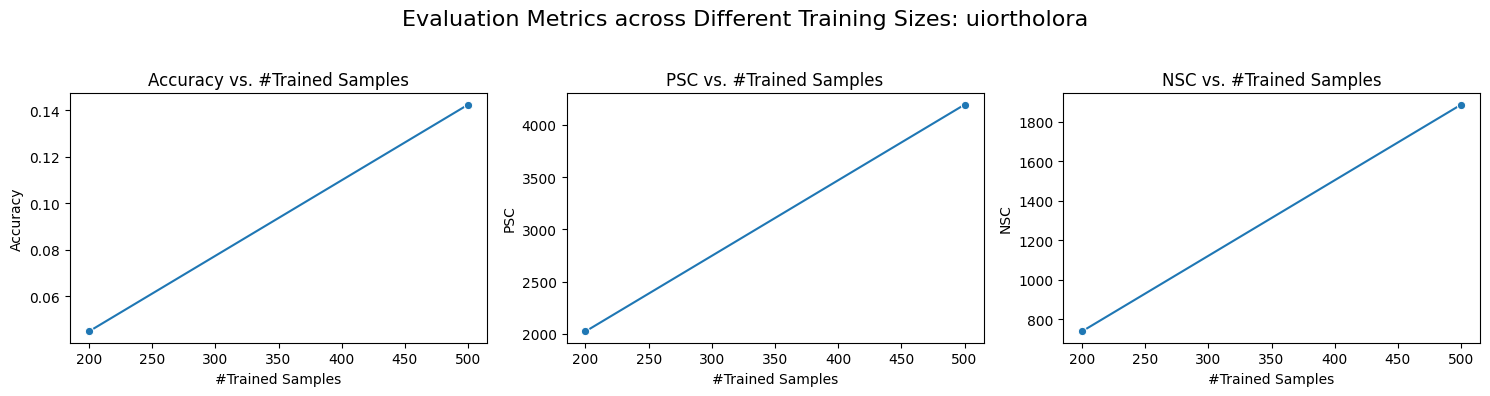

,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,meta-llama_Llama-3.2-3B_uiortholora_tr100_uior...,200,0.0450,2024.4,738.0,4549,1886
1,meta-llama_Llama-3.2-3B_uiortholora_tr500_uior...,500,0.1424,4192.4,1885.4,7202,3402


In [9]:
print(f"Evaluating adapter family across runs: {uiortholora_adapter_models}")
evaluate_single_adapter_by_trainedN(df, uiortholora_adapter_models, "uiortholora", base_model_name)

Evaluating FT model 'meta-llama_Llama-3.2-3B_uiortholora_tr100_uiortholora_s256_v64' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_uiortholora_tr100_uiortholora_s256_v64
Baseline: Llama-3.2-3B
Trained samples: 200
Accuracy: 0.045
PSC: 2024.400 (4549 samples)
NSC: 738.000 (1886 samples)


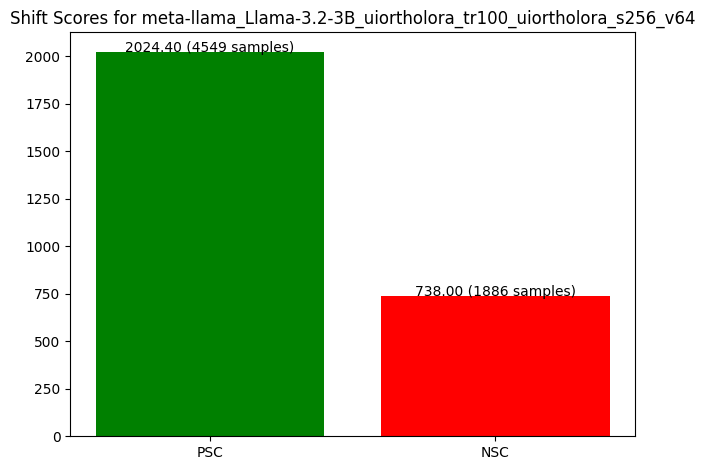

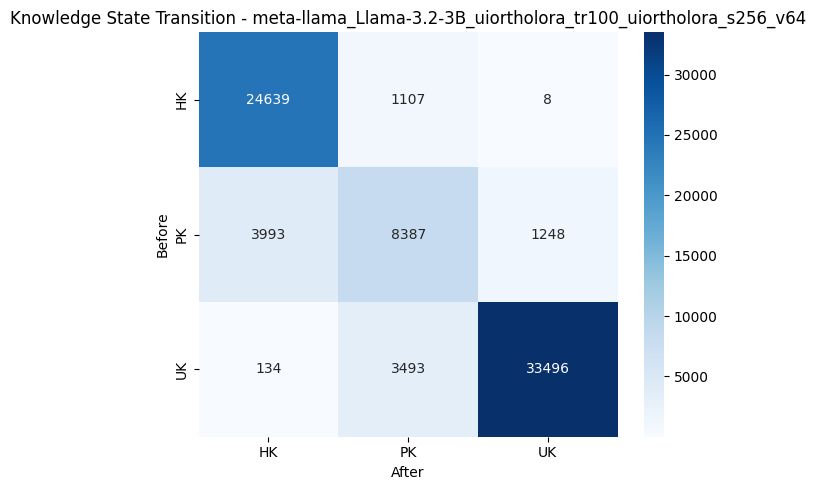

Evaluating FT model 'meta-llama_Llama-3.2-3B_uiortholora_tr500_uiortholora_s256_v64' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_uiortholora_tr500_uiortholora_s256_v64
Baseline: Llama-3.2-3B
Trained samples: 500
Accuracy: 0.142
PSC: 4192.400 (7202 samples)
NSC: 1885.400 (3402 samples)


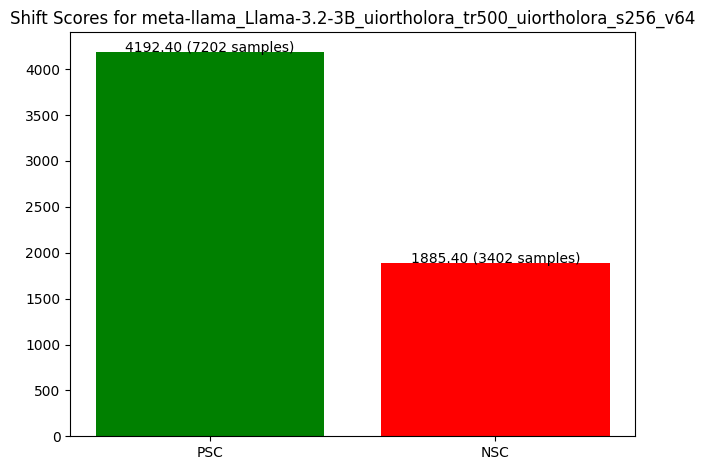

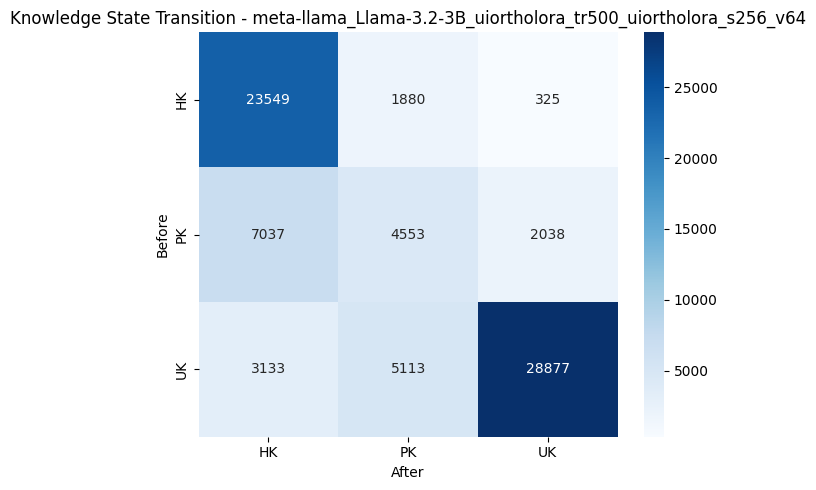

In [10]:
if ft_model_names and df["base_model_id"].notna().any():
    for ft_model_name in uiortholora_adapter_models:
        base_model_name = df["base_model_id"].dropna().unique()[0]
        print(f"Evaluating FT model '{ft_model_name}' vs baseline '{base_model_name}'")
        evaluate_single_run(df, ft_model_name, base_model_name)